In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

from ncs import load_signal
from ncs.exact_tree_projection import tree_projection
from ncs.wavelet_module import get_orthogonal_wavelets, forward_transform, inverse_transform
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
signal = load_signal(power=13, count=1)[0]
signal

array([1322,  997, 1040, ...,  969,  927,  855],
      shape=(8192,), dtype=int16)

In [20]:
coeffs = {}
results = {}
for wavelet in get_orthogonal_wavelets():
    coeffs[wavelet] = forward_transform(signal, wavelet)
    results[wavelet] = []

    for tree_sparsity in np.linspace(80, 1600, 10):
        tree_sparse_coeff = tree_projection(coeffs[wavelet], tree_sparsity)
        tree_sparse_signal = inverse_transform(tree_sparse_coeff)
        mse = np.mean((signal - tree_sparse_signal) ** 2)
        results[wavelet].append(
            {"tree_sparsity": tree_sparsity, "mse": mse}
        )

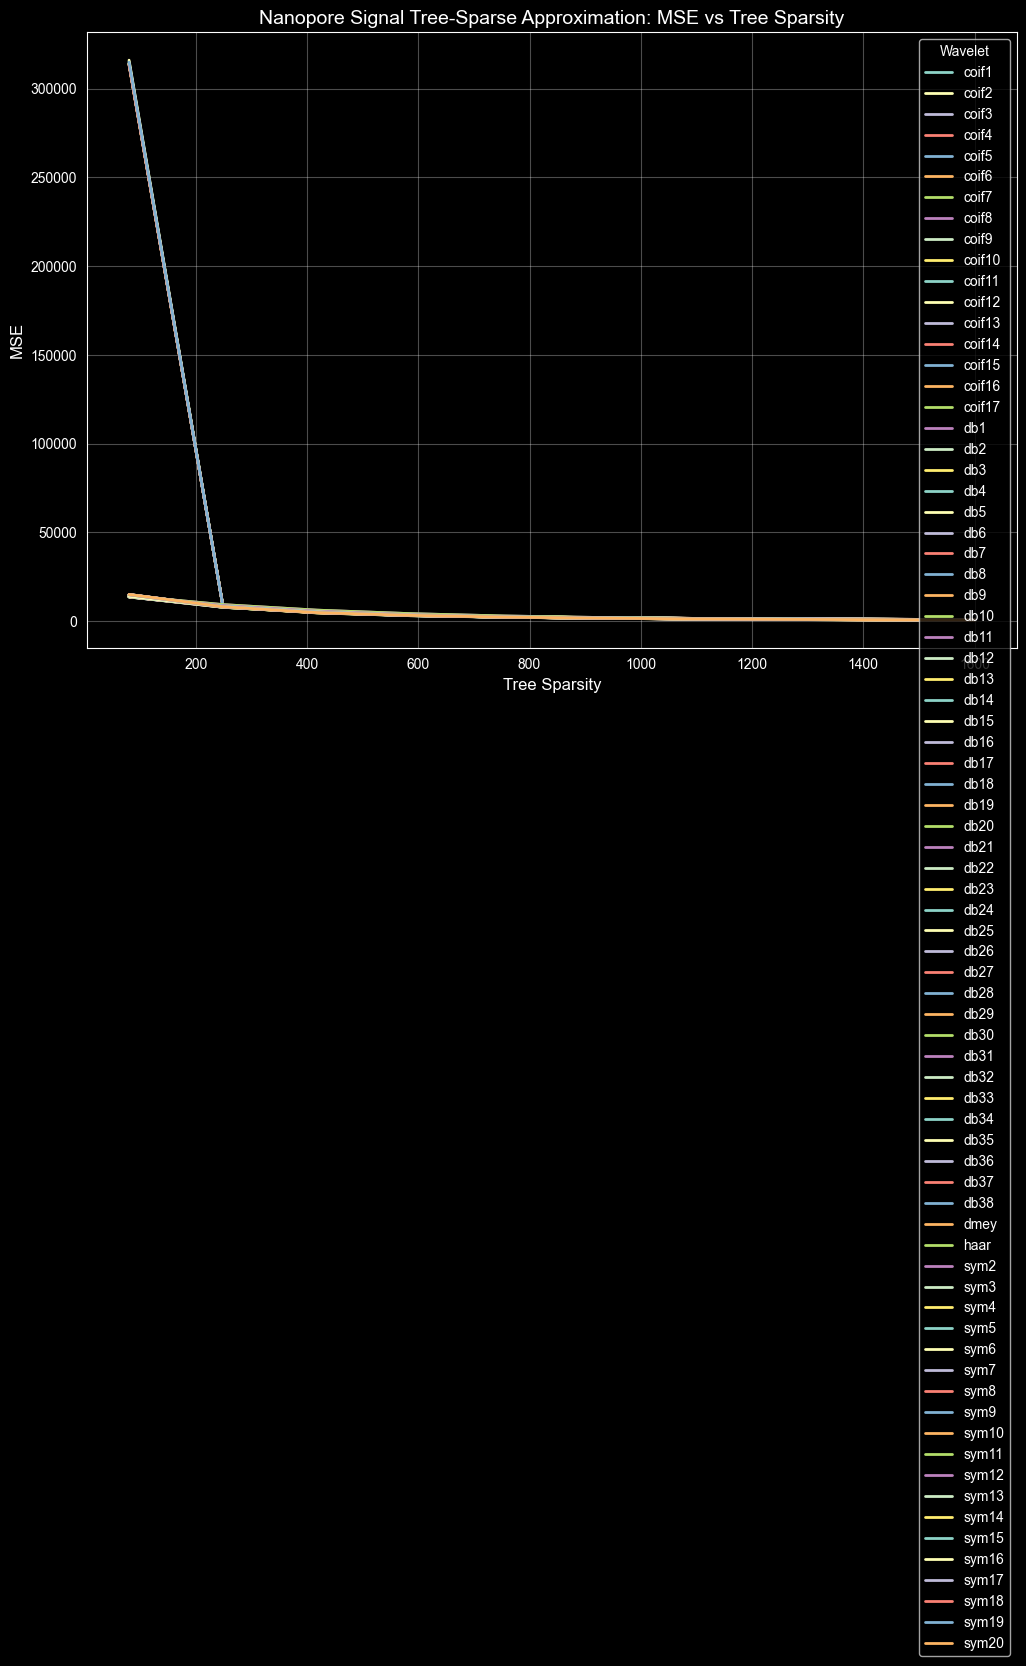

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 8))

for wavelet in results.keys():
    df = pd.DataFrame(results[wavelet])
    sns.lineplot(
        data=df,
        x="tree_sparsity",
        y="mse",
        label=wavelet,
        linewidth=2,
        ax=ax,
    )

ax.set_xlabel("Tree Sparsity", fontsize=12)
ax.set_ylabel("MSE", fontsize=12)
ax.set_title("Nanopore Signal Tree-Sparse Approximation: MSE vs Tree Sparsity", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(title="Wavelet", fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

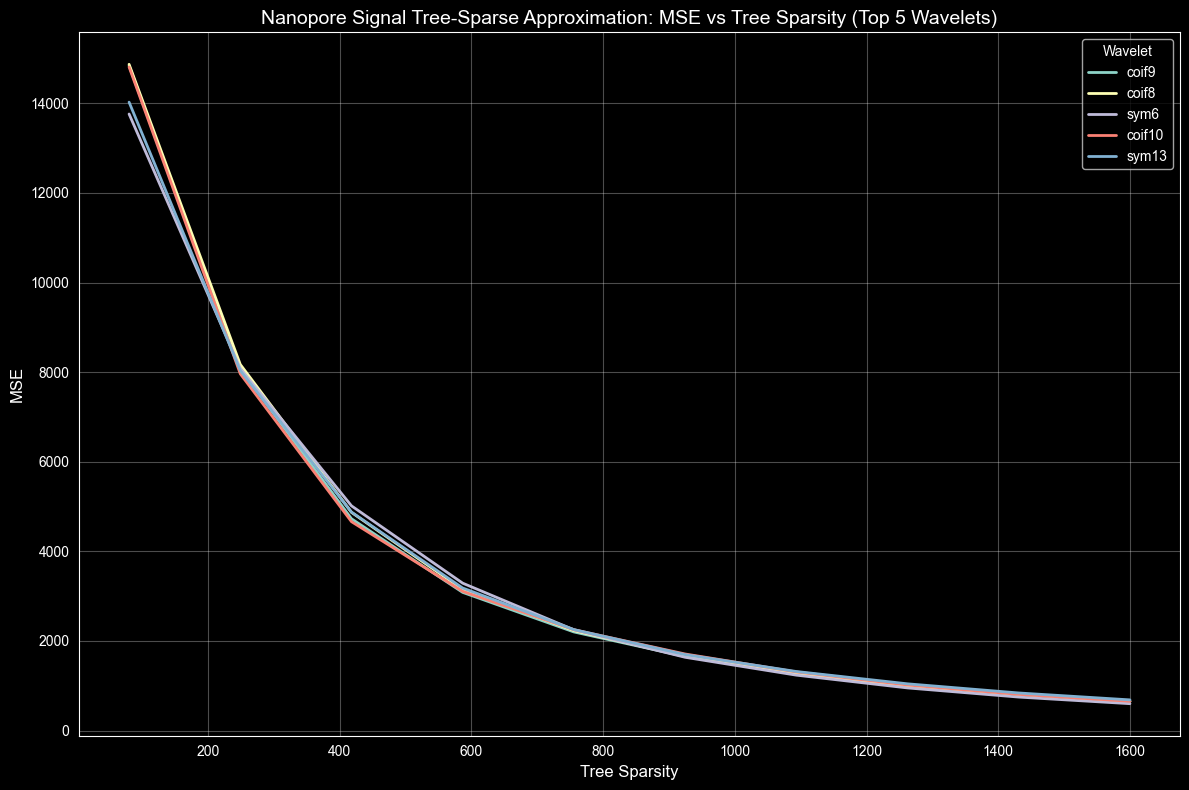

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Find the index closest to tree_sparsity = 800
tree_sparsity_values = np.linspace(80, 1600, 10)
target_idx = np.argmin(np.abs(tree_sparsity_values - 800))

# Calculate MSE at that tree_sparsity for each wavelet
wavelet_mses = {}
for wavelet in results.keys():
    mse_at_800 = results[wavelet][target_idx]["mse"]
    wavelet_mses[wavelet] = mse_at_800

# Get top 5 wavelets with smallest MSE
top_5_wavelets = sorted(wavelet_mses.items(), key=lambda x: x[1])[:5]
top_5_wavelet_names = [w[0] for w in top_5_wavelets]

print(f"Tree sparsity value used: {tree_sparsity_values[target_idx]}")
print("Top 5 wavelets with smallest MSE:")
for wavelet, mse in top_5_wavelets:
    print(f"  {wavelet}: {mse:.6f}")

# Plot only the top 5 wavelets
fig, ax = plt.subplots(figsize=(12, 8))

for wavelet in top_5_wavelet_names:
    df = pd.DataFrame(results[wavelet])
    sns.lineplot(
        data=df,
        x="tree_sparsity",
        y="mse",
        label=wavelet,
        linewidth=2,
        ax=ax,
    )

ax.set_xlabel("Tree Sparsity", fontsize=12)
ax.set_ylabel("MSE", fontsize=12)
ax.set_title("Nanopore Signal Tree-Sparse Approximation: MSE vs Tree Sparsity (Top 5 Wavelets)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(title="Wavelet", fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

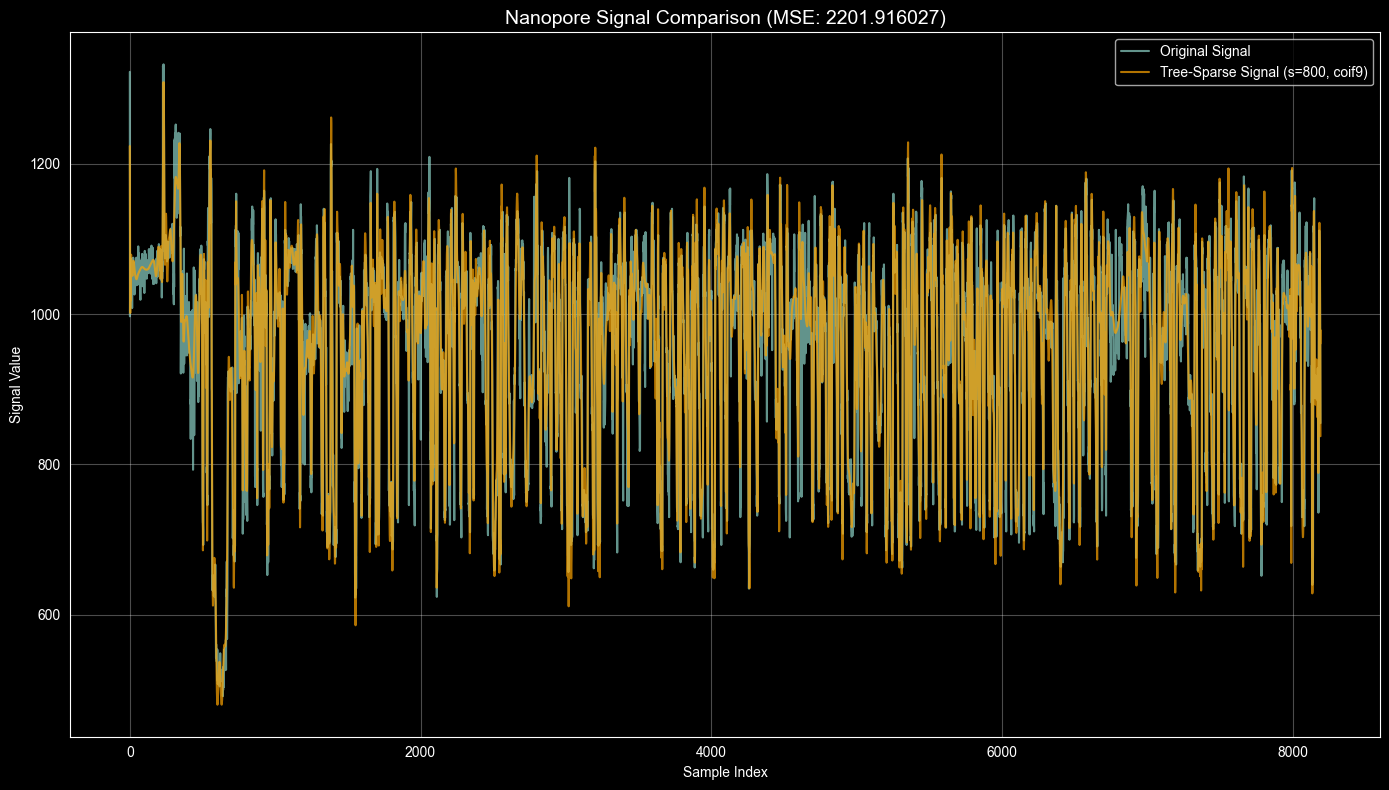

In [27]:
(best_wavelet, best_mse) = top_5_wavelets[0]
tree_sparse_coeff = tree_projection(coeffs[best_wavelet], 800)
tree_sparse_signal = inverse_transform(tree_sparse_coeff)

# Plot full signals on one graph
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(signal, label='Original Signal', alpha=0.7)
ax.plot(tree_sparse_signal, label=f'Tree-Sparse Signal (s=800, {best_wavelet})', alpha=0.7, color='orange')
ax.set_title(f'Nanopore Signal Comparison (MSE: {best_mse:.6f})', fontsize=14)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Signal Value')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

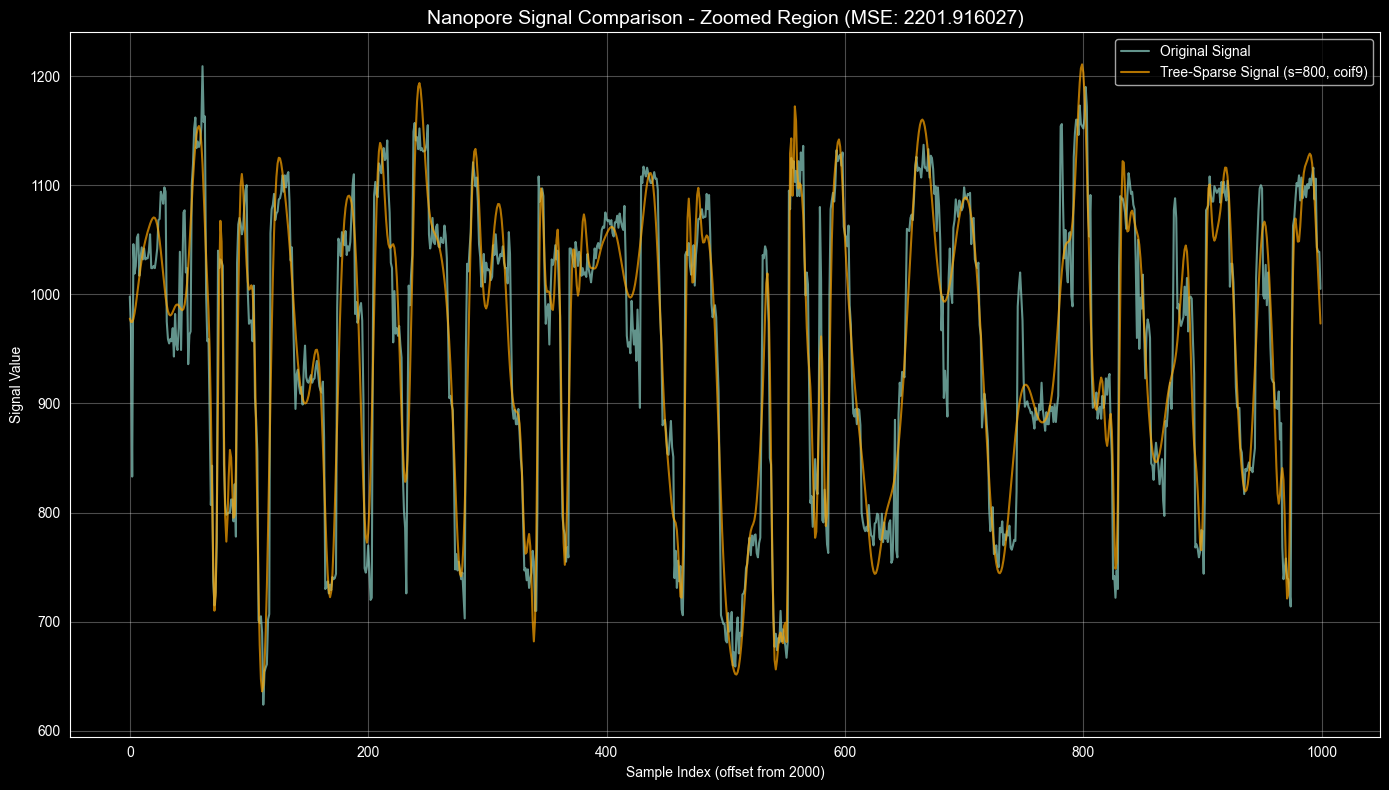

In [28]:
# Plot zoomed region (2000:4000) on one graph
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(signal[2000:3000], label='Original Signal', alpha=0.7)
ax.plot(tree_sparse_signal[2000:3000], label=f'Tree-Sparse Signal (s=800, {best_wavelet})', alpha=0.7, color='orange')
ax.set_title(f'Nanopore Signal Comparison - Zoomed Region (MSE: {best_mse:.6f})', fontsize=14)
ax.set_xlabel('Sample Index (offset from 2000)')
ax.set_ylabel('Signal Value')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

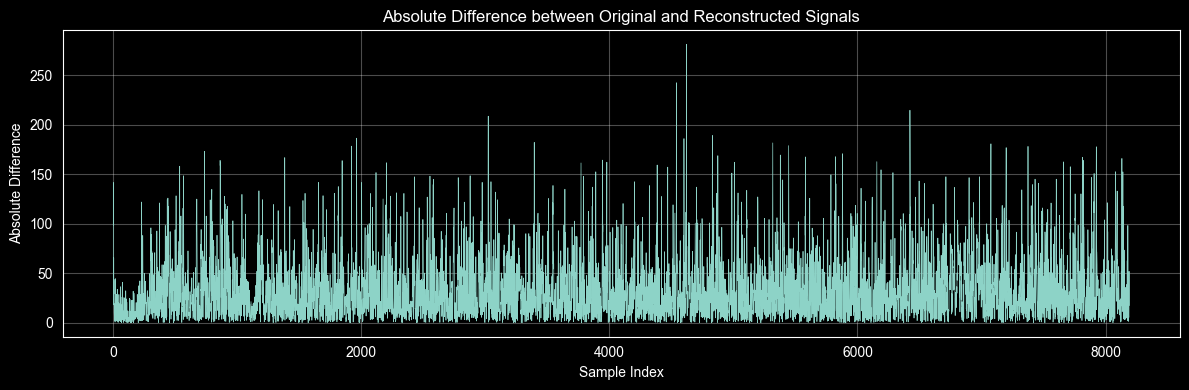

In [31]:
# Compute absolute difference
abs_diff = np.abs(signal - tree_sparse_signal)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(abs_diff, linewidth=0.5)
plt.title('Absolute Difference between Original and Reconstructed Signals')
plt.xlabel('Sample Index')
plt.ylabel('Absolute Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Optionally, print some statistics
print(f"Max absolute difference: {abs_diff.max():.6f}")
print(f"Mean absolute difference: {abs_diff.mean():.6f}")
print(f"Median absolute difference: {np.median(abs_diff):.6f}")

Max absolute difference: 281.195900
Mean absolute difference: 33.765191
Median absolute difference: 25.900894


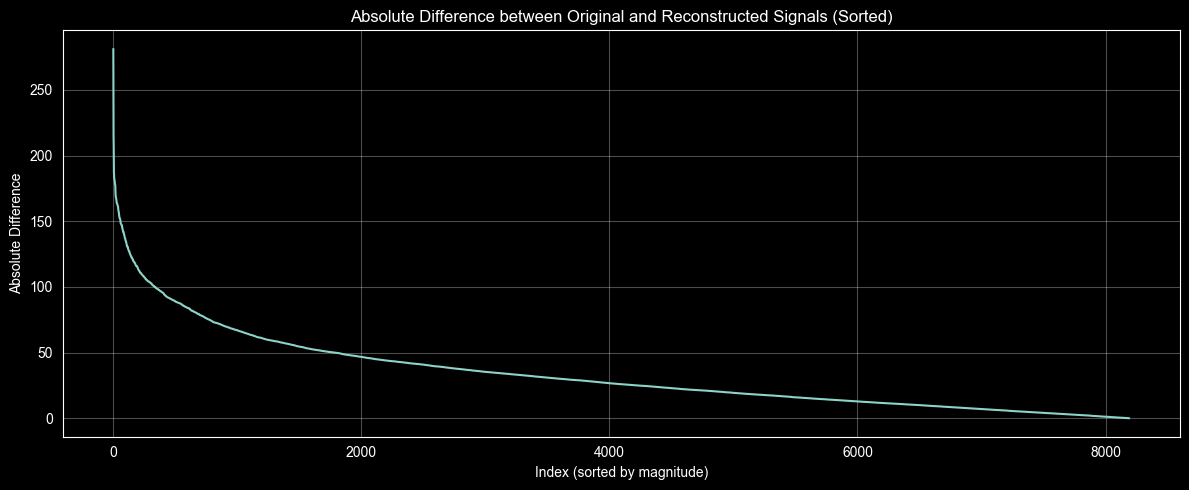

In [34]:
# Sort absolute difference from biggest to smallest
sorted_abs_diff = np.sort(abs_diff)[::-1]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(sorted_abs_diff)
plt.title('Absolute Difference between Original and Reconstructed Signals (Sorted)')
plt.xlabel('Index (sorted by magnitude)')
plt.ylabel('Absolute Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from ncs.compressed_sensing_module import measure_and_reconstruct
from tqdm import tqdm

# Define measurement range
m_values = np.linspace(800, 2000, 10).astype(int)
tree_sparsity = 800

results = []
reconstruction_attempts = 1  # Multiple attempts per m value

for m in tqdm(m_values, desc="Measuring and reconstructing"):
    for _ in range(reconstruction_attempts):
        x_hat = measure_and_reconstruct(
            measurement_mode='gaussian',
            m=int(m),
            reconstruction_mode="CoSaMP",
            coeffs_x=coeffs[best_wavelet],
            target_tree_sparsity=tree_sparsity,
        )

        original_z = signal
        reconstructed_z = inverse_transform(x_hat)

        mse = np.mean((original_z - reconstructed_z) ** 2)

        results.append({"m": m, "mse": mse})

# Create dataframe and plot
df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 8))

sns.stripplot(
    data=df,
    x="m",
    y="mse",
    jitter=0.2,
    alpha=0.7,
    color='steelblue',
    native_scale=True,
    ax=ax,
)

sns.lineplot(
    data=df,
    x="m",
    y="mse",
    estimator="mean",
    color="red",
    linewidth=2,
    errorbar=None,
    ax=ax,
    label="Mean MSE",
)

ax.set_xlabel(f"Number of Measurements (m)", fontsize=12)
ax.set_ylabel("Signal Domain MSE", fontsize=12)
ax.set_title(
    f"Nanopore Signal Reconstruction: MSE vs Number of Measurements\n(Wavelet: {best_wavelet}, Tree-sparsity: {tree_sparsity})",
    fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Measuring and reconstructing:  50%|█████     | 5/10 [06:14<06:15, 75.06s/it]

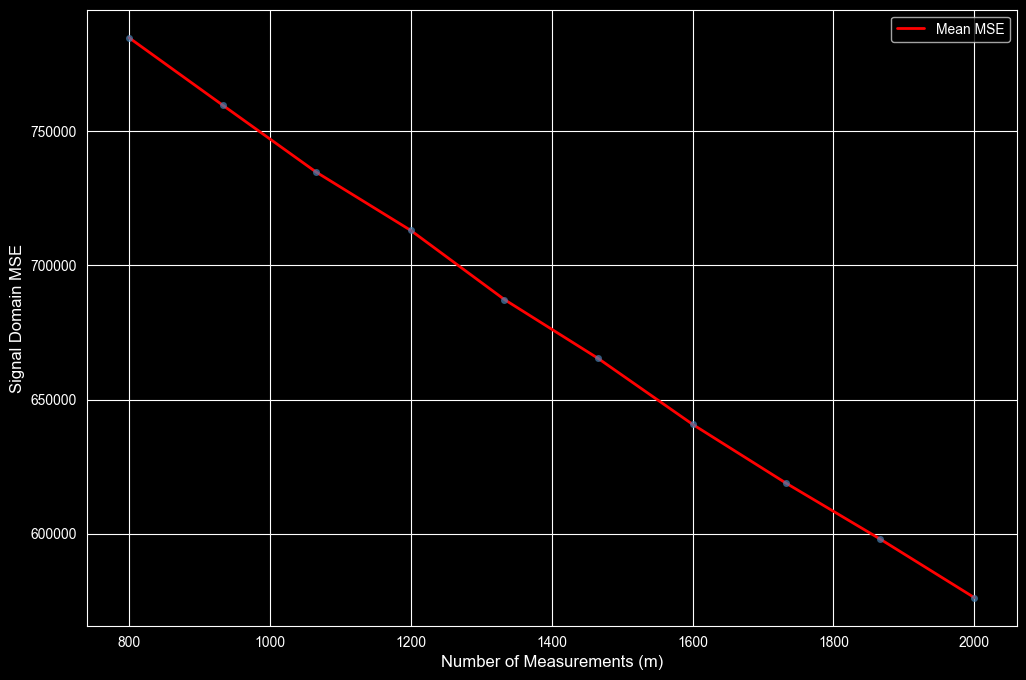

In [4]:
from ncs.compressed_sensing_module import measure_and_reconstruct
from tqdm import tqdm

# Define measurement range
m_values = np.linspace(800, 2000, 10).astype(int)
tree_sparsity = 800

results = []
reconstruction_attempts = 1  # Multiple attempts per m value

for m in tqdm(m_values, desc="Measuring and reconstructing"):
    for _ in range(reconstruction_attempts):
        x_hat = measure_and_reconstruct(
            measurement_mode='subsampling',
            m=int(m),
            reconstruction_mode="CoSaMP",
            coeffs_x=forward_transform(signal, 'coif9'),
            target_tree_sparsity=tree_sparsity,
        )

        original_z = signal
        reconstructed_z = inverse_transform(x_hat)

        mse = np.mean((original_z - reconstructed_z) ** 2)

        results.append({"m": m, "mse": mse})

# Create dataframe and plot
df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 8))

sns.stripplot(
    data=df,
    x="m",
    y="mse",
    jitter=0.2,
    alpha=0.7,
    color='steelblue',
    native_scale=True,
    ax=ax,
)

sns.lineplot(
    data=df,
    x="m",
    y="mse",
    estimator="mean",
    color="red",
    linewidth=2,
    errorbar=None,
    ax=ax,
    label="Mean MSE",
)

ax.set_xlabel(f"Number of Measurements (m)", fontsize=12)
ax.set_ylabel("Signal Domain MSE", fontsize=12)
ax.set_title(
    f"Nanopore Signal Reconstruction: MSE vs Number of Measurements\n(Wavelet: {best_wavelet}, Tree-sparsity: {tree_sparsity}, subsampling)",
    fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [5]:
x_hat = measure_and_reconstruct(
    measurement_mode='subsampling',
    m=1400,
    reconstruction_mode="CoSaMP",
    coeffs_x=forward_transform(signal, 'coif9'),
    target_tree_sparsity=tree_sparsity,
)
reconstructed_z = inverse_transform(x_hat)

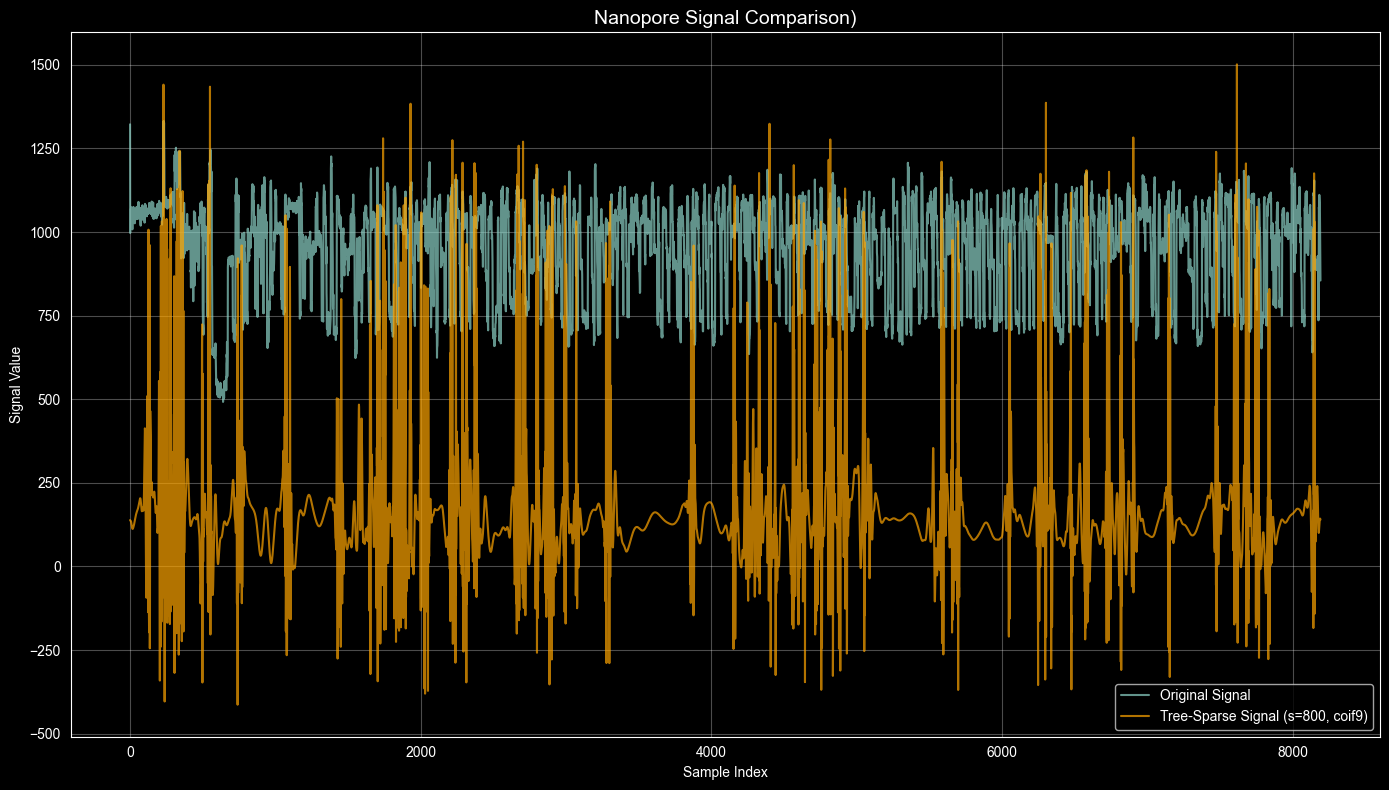

In [9]:
tree_sparse_signal = np.copy(reconstructed_z)

# Plot full signals on one graph
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(signal, label='Original Signal', alpha=0.7)
ax.plot(tree_sparse_signal, label=f'Tree-Sparse Signal (s=800, coif9)', alpha=0.7, color='orange')
ax.set_title(f'Nanopore Signal Comparison)', fontsize=14)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Signal Value')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

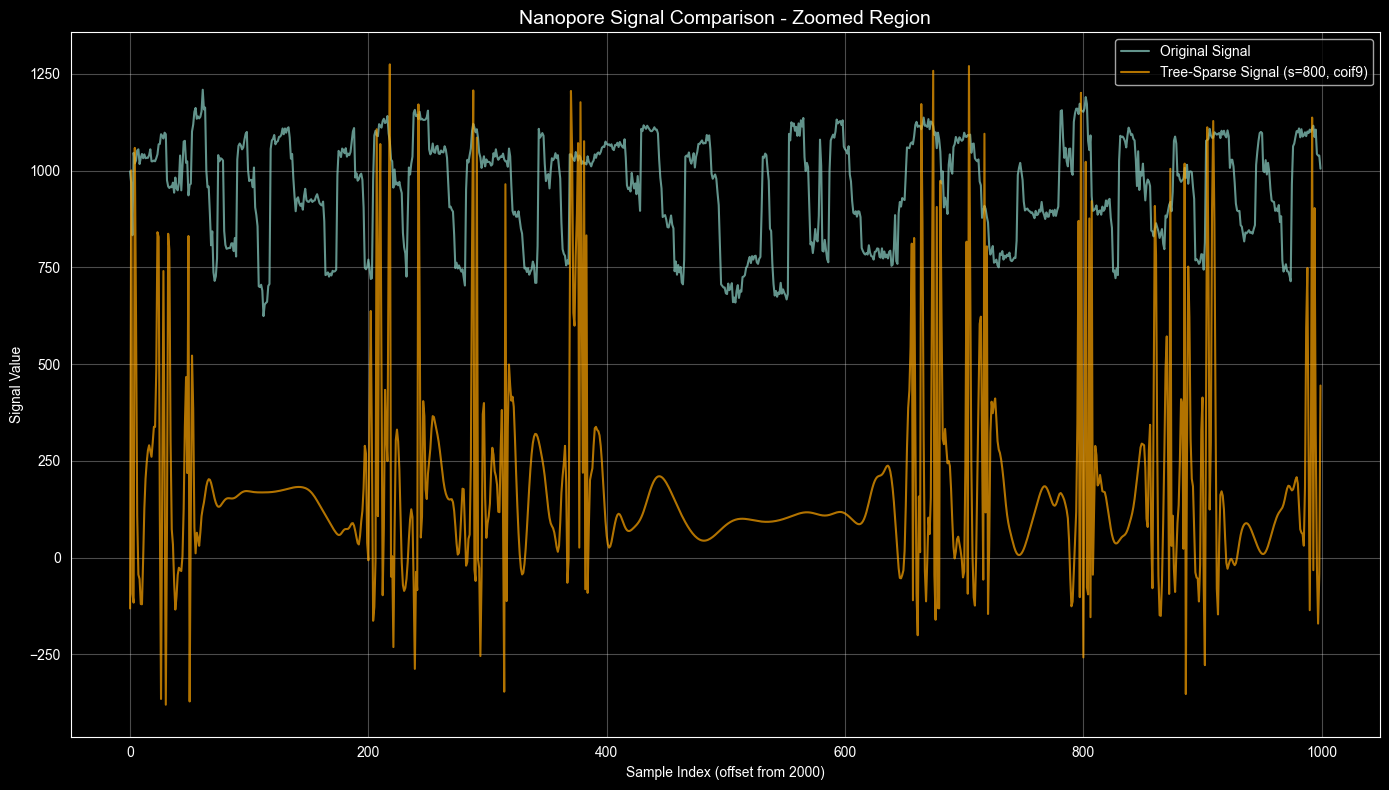

In [10]:
# Plot zoomed region (2000:4000) on one graph
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(signal[2000:3000], label='Original Signal', alpha=0.7)
ax.plot(tree_sparse_signal[2000:3000], label=f'Tree-Sparse Signal (s=800, coif9)', alpha=0.7, color='orange')
ax.set_title(f'Nanopore Signal Comparison - Zoomed Region', fontsize=14)
ax.set_xlabel('Sample Index (offset from 2000)')
ax.set_ylabel('Signal Value')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

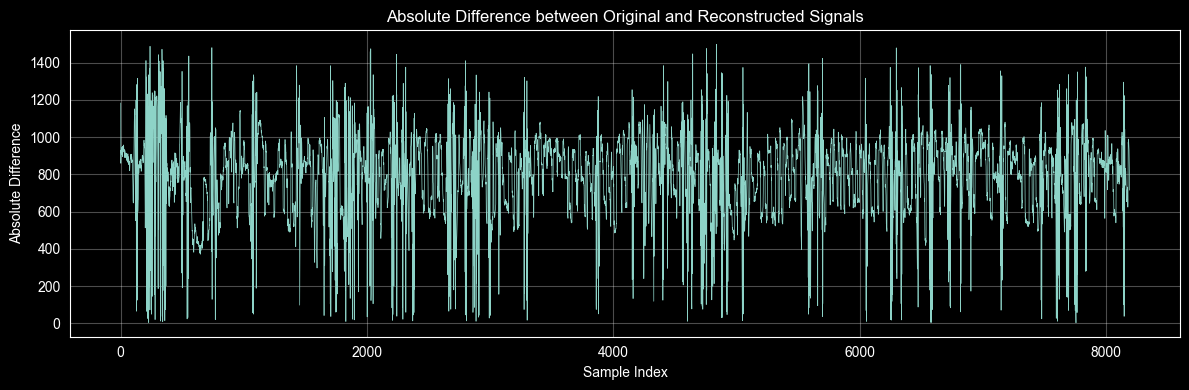

In [11]:
# Compute absolute difference
abs_diff = np.abs(signal - tree_sparse_signal)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(abs_diff, linewidth=0.5)
plt.title('Absolute Difference between Original and Reconstructed Signals')
plt.xlabel('Sample Index')
plt.ylabel('Absolute Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

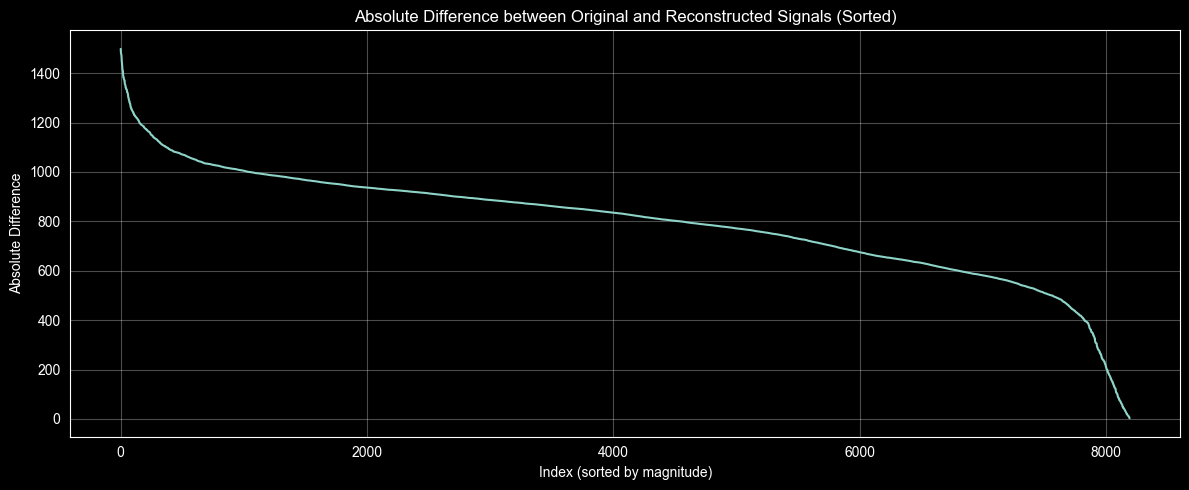

In [12]:
# Sort absolute difference from biggest to smallest
sorted_abs_diff = np.sort(abs_diff)[::-1]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(sorted_abs_diff)
plt.title('Absolute Difference between Original and Reconstructed Signals (Sorted)')
plt.xlabel('Index (sorted by magnitude)')
plt.ylabel('Absolute Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()